# COMP 6934 Winter 2026 In class Work 16X

Table idioms per Tamara Munzner chapter 7.


Isaac Edem Adoboe - ieadoboe@mun.ca

### Problem Set 16

Extension of problem set 14 and 15.


In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("taxis.csv")
df.head()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   pickup           6433 non-null   str    
 1   dropoff          6433 non-null   str    
 2   passengers       6433 non-null   int64  
 3   distance         6433 non-null   float64
 4   fare             6433 non-null   float64
 5   tip              6433 non-null   float64
 6   tolls            6433 non-null   float64
 7   total            6433 non-null   float64
 8   color            6433 non-null   str    
 9   payment          6389 non-null   str    
 10  pickup_zone      6407 non-null   str    
 11  dropoff_zone     6388 non-null   str    
 12  pickup_borough   6407 non-null   str    
 13  dropoff_borough  6388 non-null   str    
dtypes: float64(5), int64(1), str(8)
memory usage: 703.7 KB


In [4]:
df.describe()

,passengers,distance,fare,tip,tolls,total
count,6433.000000,6433.000000,6433.000000,6433.00000,6433.000000,6433.000000
mean,1.539251,3.024617,13.091073,1.97922,0.325273,18.517794
std,1.203768,3.827867,11.551804,2.44856,1.415267,13.815570
min,0.000000,0.000000,1.000000,0.00000,0.000000,1.300000
25%,1.000000,0.980000,6.500000,0.00000,0.000000,10.800000
50%,1.000000,1.640000,9.500000,1.70000,0.000000,14.160000
75%,2.000000,3.210000,15.000000,2.80000,0.000000,20.300000
max,6.000000,36.700000,150.000000,33.20000,24.020000,174.820000


In [5]:
df.shape

(6433, 14)

#### Problem 16.1

Conduct a munzner-style *what* analysis of the taxis.csv data set. You may copy your solution from problems sets 14 and 15 for this. 

## WHAT

**Dataset Type**: Table

**Dataset Availability**: Static

**Attribute Types**: 
| Feature | Definition |
|----------|-----------|
| pickup | Quantitative |
| dropoff | Quantitative |
| passengers |Quantitative|
| distance | Quantitative|
| fare | Quantitative|
| tip |Quantitative |
| tolls | Quantitative|
| total | Quantitative|
| color | Categorical (nominal) |
| payment | Categorical (nominal) |
| pickup_zone | Categorical (nominal)|
| dropoff_zone | Categorical (nominal)|
| pickup_borough | Categorical (nominal)|
| dropoff_borough | Categorical (nominal)|

#### Problem 16.2

Conduct a munzner-style *why* analysis of at least one goal-oriented question for the taxis.csv data set. You may copy the question and your solution from problems sets 14 and 15 for this.

## WHY

**Question 1: "What factors affect or influence tipping?"**

**Goal:** Understand which features/variables have explanatory power over tip behavior.

**Action/Target Pairs**:

| # | Action | Target | Reasoning |
|---|--------|--------|-----------|
| 1.1 | **Correlate** | {distance, tip} | Quantitative association: does longer rides → higher tips? |
| 1.2 | **Correlate** | {fare, tip} | Quantitative association: does higher fare → higher tips? |
| 1.3 | **Correlate** | {passengers, tip} | Quantitative association: group size effect on tipping? |
| 1.4 | **Compare** | {payment method} vs {tip amount} | Categorical split: do credit card users tip differently than cash? |
| 1.5 | **Compare** | {time of day} vs {tip amount} | Temporal pattern: do rush hours, nights, weekends affect tipping? |
| 1.6 | **Identify** | {zero vs non-zero tips} by {payment type} | Categorical anomaly: which groups have high non-tipping rates? |
| 1.7 | **Summarize** | {tip as % of fare} across {all factors} | Derive new attribute (tip ratio) and test its relationships |

**Question 2: "Does one part of New York produce higher tips?"**

**Goal**: Geographic/spatial comparison of tip behavior.

**Action/Target Pairs**:

| # | Action | Target | Reasoning |
|---|--------|--------|-----------|
| 2.1 | **Compare** | {pickup_borough} vs {mean tip} | Aggregate: which borough has highest average tips? |
| 2.2 | **Compare** | {pickup_zone} vs {mean tip} | Finer granularity: which specific zone leads? |
| 2.3 | **Rank** | {pickup_borough or pickup_zone} by {tip amount} | Order geographic regions by tipping magnitude |
| 2.4 | **Identify** | {high-tip zones} and {low-tip zones} | Categorical segmentation: which areas are outliers? |
| 2.5 | **Compare** | {pickup_borough} vs {dropoff_borough} | Directional analysis: do intra-borough vs cross-borough trips differ? |

**Question 3: "Show that distance travelled affects tips.**

**Goal**: Demonstrate causal/correlational relationship; persuasive evidence.

**Action/Target Pairs**:

| # | Action | Target | Reasoning |
|---|--------|--------|-----------|
| 3.1 | **Correlate** | {distance, tip} | Quantitative association with strength (correlation coeff) |
| 3.2 | **Compare** | {distance quartiles} vs {median tip per quartile} | Binned comparison: does tip increase monotonically with distance? |
| 3.3 | **Derive & Correlate** | {distance, tip ratio (tip/fare)} | Control for confound: is it distance or fare? |
| 3.4 | **Identify** | {outliers and trend} in {distance-tip scatter} | Visual regression: show linear fit + residuals to make relationship clear |
| 3.5 | **Summarize** | {distance ranges} and {corresponding tip distributions} | Aggregate: mean, median, quartiles for each distance band |

#### Problem 16.3

Implement a visualization plot to address one action/target pair developed in your solution to problem 16.2. The action/target and plot should involve at least three attributes from the data set (one dependent and two independent variables) and an idiom from chapter 7 of munzner so it is suitable for the next problem 16.4. You may use a visualization from your solution to problems 14 and 15.

For **Question 1: "What factors affect or influence tipping?"**, I chose 1.1 {distance, tip}

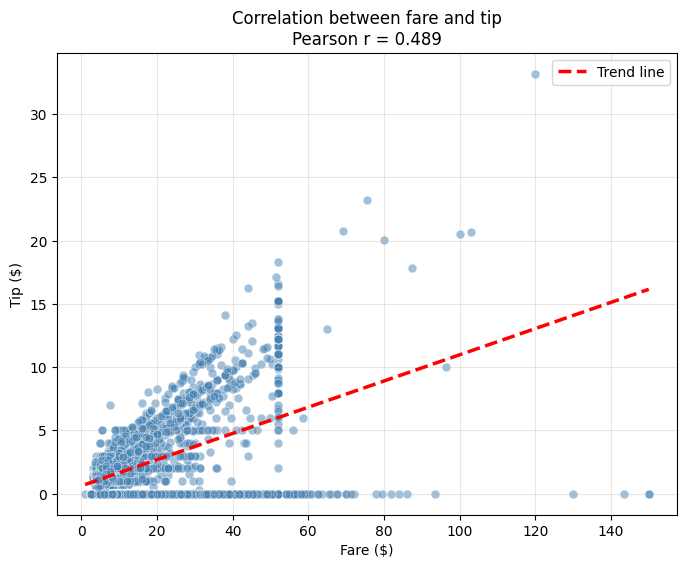

In [42]:
plt.figure(figsize=(8, 6))
fig = sns.scatterplot(
    data=df,
    x='fare',
    y='tip',
    alpha=0.5,
    s=40,
    color='steelblue'
)

# Add  trend line
z = np.polyfit(df['fare'], df['tip'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['fare'].min(), df['fare'].max(), 100)
fig.plot(x_line, p(x_line), "r--", linewidth=2.5,
         label=f'Trend line')

# Calculate correlation coefficient
corr = df['fare'].corr(df['tip'])

plt.title(
    f'Correlation between fare and tip\n'
    f'Pearson r = {corr:.3f}')
plt.ylabel("Tip ($)")
plt.xlabel("Fare ($)")

plt.grid(alpha=0.3)
plt.legend()
plt.show()

For **Question 2: "Does one part of New York produce higher tips?"**, I chose 2.1 {pickup_borough, mean tip}

In [37]:
borough_tips = df.groupby('pickup_borough')['tip'].mean().sort_values(
    ascending=False
).reset_index()
borough_tips

,pickup_borough,tip
0,Queens,3.040061
1,Manhattan,1.939550
2,Brooklyn,0.966345
3,Bronx,0.148586


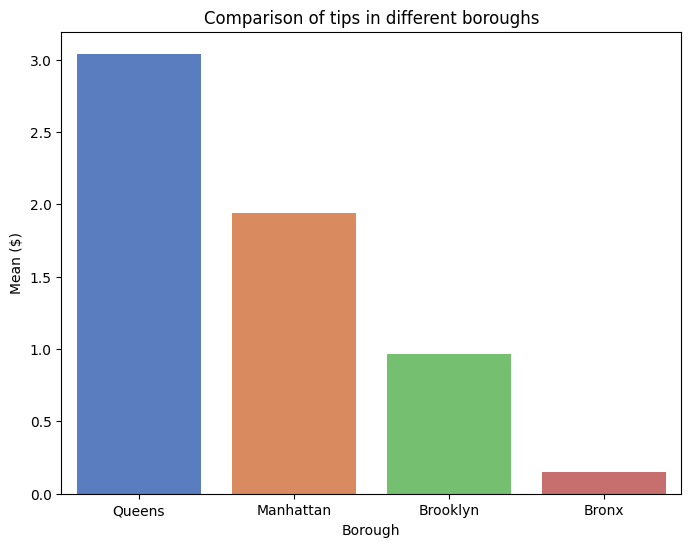

In [45]:
plt.figure(figsize=(8, 6))
fig = sns.barplot(
    data=borough_tips,
    x='pickup_borough',
    y='tip',
    hue='pickup_borough',
    palette='muted',
    legend=False
)

plt.title('Comparison of tips in different boroughs')
plt.ylabel("Mean ($)")
plt.xlabel("Borough")

plt.show()

For **Question 3: "What factors affect or influence tipping?"**, I chose 3.1 {distance, tip}

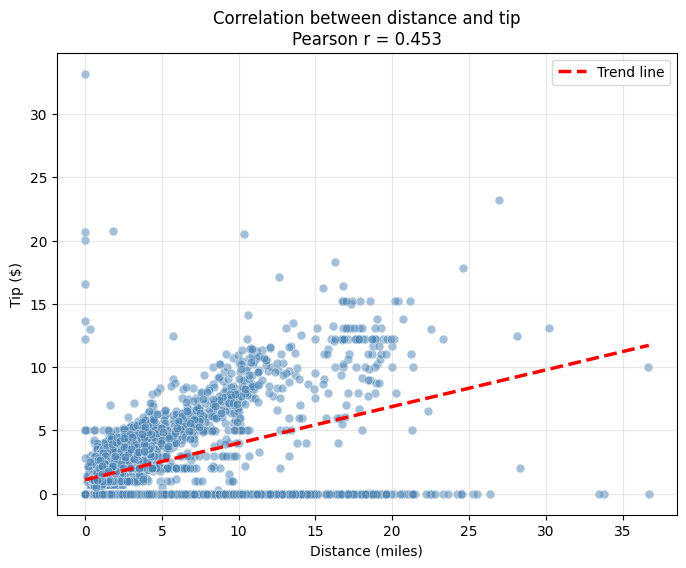

In [39]:
plt.figure(figsize=(8, 6))
fig = sns.scatterplot(
    data=df,
    x='distance',
    y='tip',
    alpha=0.5,
    s=40,
    color='steelblue'
)

# Add  trend line
z = np.polyfit(df['distance'], df['tip'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['distance'].min(), df['distance'].max(), 100)
fig.plot(x_line, p(x_line), "r--", linewidth=2.5,
         label=f'Trend line')

# Calculate correlation coefficient
corr = df['distance'].corr(df['tip'])

plt.title(
    f'Correlation between distance and tip\n'
    f'Pearson r = {corr:.3f}')
plt.ylabel("Tip ($)")
plt.xlabel("Distance (miles)")

plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [ ]:


ax.set_title(
    'PLOT 1: COMPARE {payment} vs {mean tip}\n'
    'Action: Compare | Target: payment_method, tip_amount',
    fontsize=11,
    fontweight='bold'
)
ax.set_xlabel('Payment Method', fontsize=10)
ax.set_ylabel('Mean Tip ($)', fontsize=10)
ax.set_ylim(0, max(payment_tips['mean']) * 1.3)

# Add value labels on bars
for i, (idx, row) in enumerate(payment_tips.iterrows()):
    ax.text(i, row['mean'] + 0.15, f"${row['mean']:.2f}",
            ha='center', fontsize=9, fontweight='bold')

return ax

#### Problem 16.4

This answer will carry most of the credit for this problem set, so spend some time here.

Discuss the application of one idiom identified by munzner in your solution to 16.3, relating the *how* choices to the *what* an *why* of this visalization. Include the following:

* The name of the idiom and any variation from munzner's "standard" description of this idiom.
* How the idiom is appropriate for the action/target and the specific domain (topic) and data in this data set.
* The encoding: the use of channels and marks under this idiom
    * including how they are appropriate for the specific action/target and the goal question
    * including how they are appropriate for the specific data and attributes used
    * including how the choices are approriate for the particular topic of the data set
* Include any limitations of this idiom that are relevant to the visualization result
* (Optional) you may suggest weaknesses or failures of the visualization result, and any improvements that could be attempted to improve the visualization. 

## Idiom: Bar chart

For my task, for **Question 2: "Does one part of New York produce higher tips?"**, I chose a bar chart because:


* I had aggregated the data tips of each borough into **one value**, the **mean tip amount** paid to the driver. Bar charts are great for visualizations that have very feature categories (4 in this case) and a single value for each category. One categorical variable, One quantitative attribute describing it.
* Bar charts use length to express different quantitative values. This is good because studies show that human beings can better perceive length than other quants (e.g. area).
* The goal of the task was to **COMPARE**. In Munerzer's video, she explained that it is easier for the viewers/audience to perceive aligned bars (or visualizations in general) to understand the scale of comparisons.
* In the task, I used different hues as well to differentiate between boroughs.

# Attributions

Be sure to add your own sources or indicate you have none to add.  Sources can be web sites, text materials, and so on. They do not have to be hyperlinks. Other people are also sources, but they are not allowed for in class credit problems.

| Source | What is it | How used |
|--|--|--|
| https://github.com/mwaskom/seaborn-data Seaborn data samples | data sets | taken directly as csv files  |
| T. Munzner book https://www.cs.ubc.ca/~tmm/vadbook/| methodology for analysis and design | design choice methods |